## PyTorch & Matplotlib & Seaborn training
### (E-commerce Customer Behavior Dataset)

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, confusion_matrix, classification_report, roc_auc_score, roc_curve, recall_score, f1_score

df = pd.read_csv('customer_behavior.csv')
df.head()

,Customer ID,Gender,Age,City,Membership Type,Total Spend,Items Purchased,Average Rating,Discount Applied,Days Since Last Purchase,Satisfaction Level
0,101,Female,29,New York,Gold,1120.20,14,4.6,True,25,Satisfied
1,102,Male,34,Los Angeles,Silver,780.50,11,4.1,False,18,Neutral
2,103,Female,43,Chicago,Bronze,510.75,9,3.4,True,42,Unsatisfied
3,104,Male,30,San Francisco,Gold,1480.30,19,4.7,False,12,Satisfied
4,105,Male,27,Miami,Silver,720.40,13,4.0,True,55,Unsatisfied


In [2]:
df['City'].value_counts()

City
New York         59
Los Angeles      59
Chicago          58
San Francisco    58
Miami            58
Houston          58
Name: count, dtype: int64

In [3]:
df.dropna(inplace=True)
print(f"{df.duplicated().sum()} - количество дубликотов")
df.shape
df.describe()

0 - количество дубликотов


,Customer ID,Age,Total Spend,Items Purchased,Average Rating,Days Since Last Purchase
count,348.000000,348.000000,348.000000,348.000000,348.000000,348.000000
mean,275.887931,33.577586,847.793103,12.632184,4.023563,26.614943
std,101.304611,4.878024,361.692375,4.146079,0.579145,13.474750
min,101.000000,26.000000,410.800000,7.000000,3.000000,9.000000
25%,188.750000,30.000000,505.750000,9.000000,3.500000,15.000000
50%,276.500000,32.000000,780.200000,12.000000,4.100000,23.000000
75%,363.250000,37.000000,1160.600000,15.000000,4.500000,38.000000
max,450.000000,43.000000,1520.100000,21.000000,4.900000,63.000000


#### Удаляем малоинформативный признак ID

In [4]:
df.drop(axis=1, labels='Customer ID', inplace=True)
df.head()

,Gender,Age,City,Membership Type,Total Spend,Items Purchased,Average Rating,Discount Applied,Days Since Last Purchase,Satisfaction Level
0,Female,29,New York,Gold,1120.20,14,4.6,True,25,Satisfied
1,Male,34,Los Angeles,Silver,780.50,11,4.1,False,18,Neutral
2,Female,43,Chicago,Bronze,510.75,9,3.4,True,42,Unsatisfied
3,Male,30,San Francisco,Gold,1480.30,19,4.7,False,12,Satisfied
4,Male,27,Miami,Silver,720.40,13,4.0,True,55,Unsatisfied


In [5]:
# Количество обьектов каждого класса
df['Satisfaction Level'].value_counts(normalize=True)

Satisfaction Level
Satisfied      0.359195
Unsatisfied    0.333333
Neutral        0.307471
Name: proportion, dtype: float64

In [6]:
df['membership_encoded'] = df['Membership Type'].map({'Bronze': 0, 'Silver': 1, 'Gold': 2})
df = pd.get_dummies(df, columns=['City'])
df['satisfaction_encoded'] = df['Satisfaction Level'].map({'Unsatisfied': 0, 'Neutral': 1, 'Satisfied': 2})
df.drop(['Gender', 'Membership Type', 'Satisfaction Level'], axis=1, inplace=True)
df.head()

,Age,Total Spend,Items Purchased,Average Rating,Discount Applied,Days Since Last Purchase,membership_encoded,City_Chicago,City_Houston,City_Los Angeles,City_Miami,City_New York,City_San Francisco,satisfaction_encoded
0,29,1120.20,14,4.6,True,25,2,False,False,False,False,True,False,2
1,34,780.50,11,4.1,False,18,1,False,False,True,False,False,False,1
2,43,510.75,9,3.4,True,42,0,True,False,False,False,False,False,0
3,30,1480.30,19,4.7,False,12,2,False,False,False,False,False,True,2
4,27,720.40,13,4.0,True,55,1,False,False,False,True,False,False,0


### Потренерую построение базовых графиков

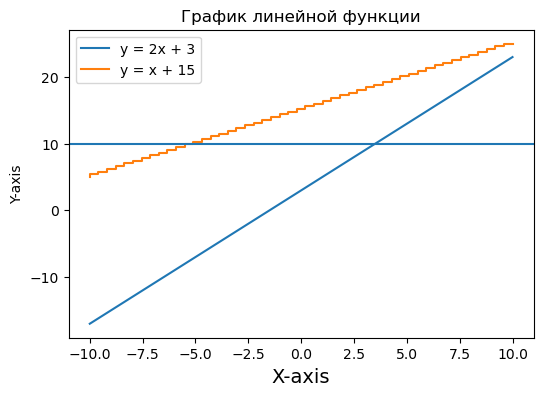

In [7]:
df_copy_cv = df.copy()
x = np.linspace(-10, 10, 50)
y_1 = 2*x + 3
y_2 = x + 15
plt.figure(figsize=(6, 4))
plt.plot(x, y_1, label='y = 2x + 3')
plt.step(x, y_2, label='y = x + 15')
plt.title("График линейной функции")
plt.xlabel("X-axis", fontsize=14 )
#plt.plot(x, np.random.randint(-15, 15, 50), label='randm')
plt.axhline(y=10)
plt.ylabel("Y-axis")
plt.legend()

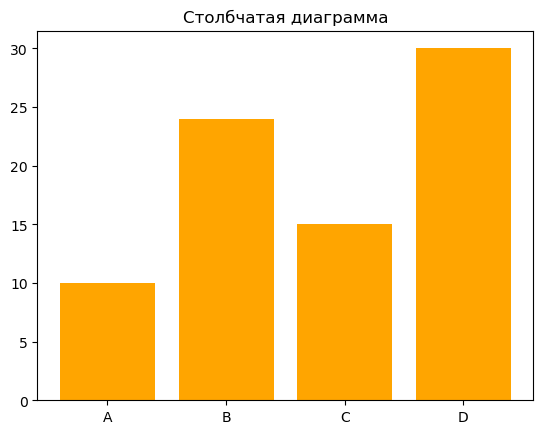

In [8]:
categories = ['A', 'B', 'C', 'D']
values = [10, 24, 15, 30]
plt.bar(categories, values, color='orange')
plt.title('Столбчатая диаграмма')
plt.show()

📌 Задача
Построй сетку из четырёх графиков (2x2) на одном холсте.

Данные:

x = np.linspace(0, 10, 100)

y1 = sin(x)

y2 = cos(x)

y3 = sin(x) + шум (np.random.randn(100) * 0.2)

y4 = np.random.normal(3, 2.4, 1000)

Графики:

Верхний левый — y1, синяя сплошная линия.

Верхний правый — y2, красная точечная линия (':').

Нижний левый — y3, оранжевые точки (scatter).

Нижний правый — гистограмма y4, розовая, 20 бинов.

Требования:

Размер холста: (10, 8).

Общий заголовок: "Мой первый subplots".

У каждого графика — подпись (set_title).

Добавить plt.tight_layout().

Отобразить график.

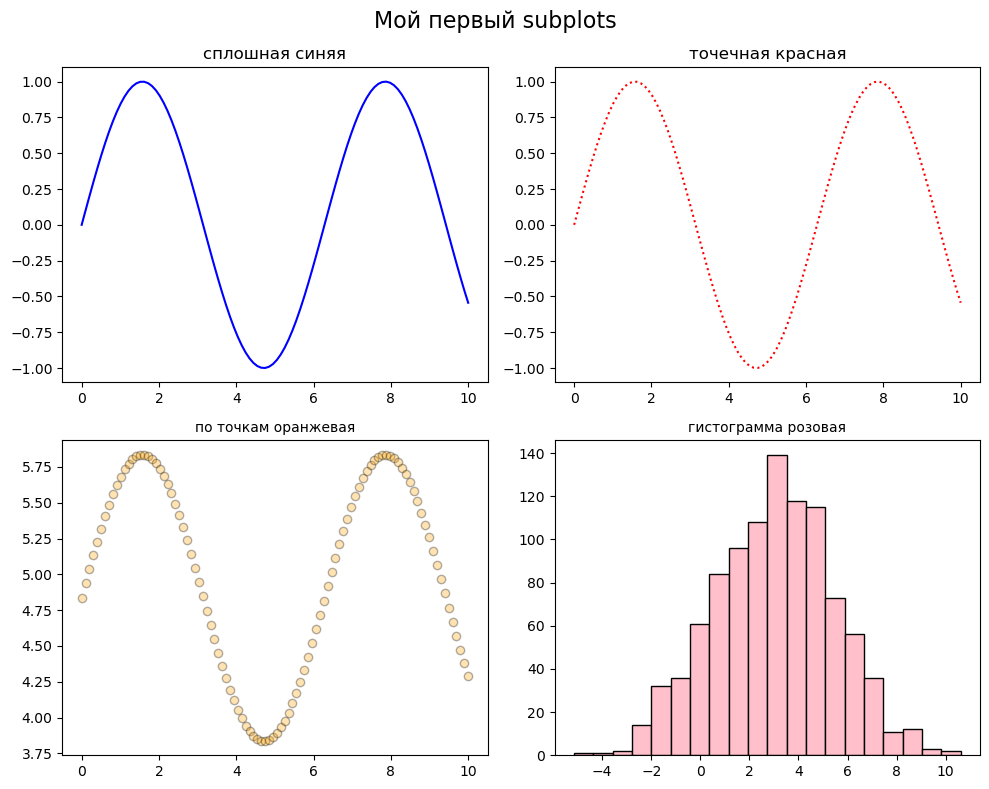

In [9]:
x = np.linspace(0, 10, 100)
y_1 = np.sin(x)
y_2 = np.cos(x)
y_3 = np.sin(x) + np.random.randn()*22
y_4 = np.random.normal(3, 2.4, 1000)
fig, kartinki = plt.subplots(2,2, figsize=(10,8))
fig.suptitle("Мой первый subplots", fontsize=16)
kartinki[0,0].plot(x, y_1, color = 'blue', ls='-')
kartinki[0,0].set_title('сплошная синяя')
kartinki[0,1].plot(x, y_1, color='red', ls=':')
kartinki[0,1].set_title('точечная красная')
kartinki[1,0].scatter(x, y_3, color='orange', alpha = 0.3, edgecolor='black')
kartinki[1,0].set_title('по точкам оранжевая', fontsize=10)
kartinki[1,1].hist(y_4, bins = 20, color='pink', edgecolor='black')
kartinki[1,1].set_title('гистограмма розовая', fontsize=10)
plt.tight_layout()
plt.show()

## EDA с графиками
(matplotlib + seaborn)

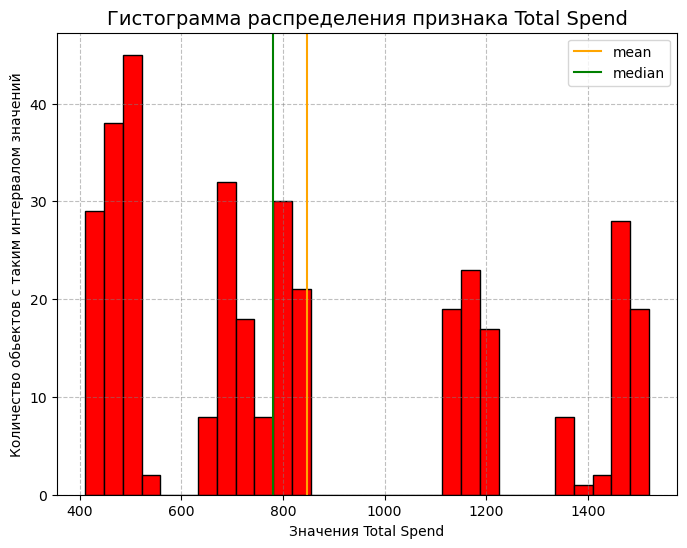

In [10]:
# 1. Построй гистограмму распределения Total Spend. Добавь вертикальные линии для среднего и медианы.
plt.figure(figsize = (8,6))
plt.hist(df['Total Spend'], bins=30,  color='red', edgecolor='black')
plt.title("Гистограмма распределения признака Total Spend", fontsize = 14)
plt.axvline(df['Total Spend'].mean(), color = 'orange', label='mean')
plt.axvline(df['Total Spend'].median(), color = 'green', label = 'median')
plt.xlabel('Значения Total Spend')
plt.ylabel('Количество обьектов с таким интервалом значений')
plt.grid(True, linestyle='--', alpha=0.5, color='gray')
plt.legend()
plt.show()

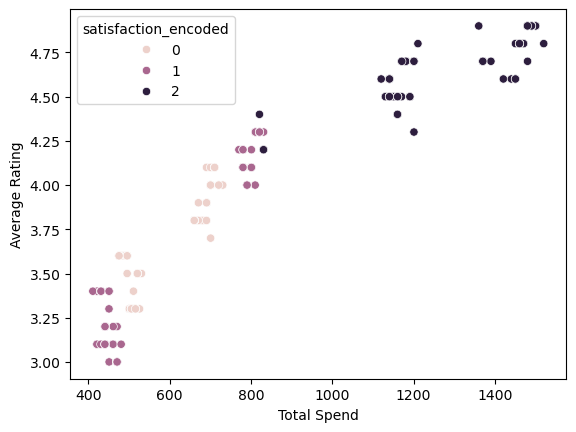

In [11]:
# 2. Построй scatterplot: Total Spend (x) vs Average Rating (y), раскрасив точки по Satisfaction Level.
sns.scatterplot(data=df, x= 'Total Spend', y='Average Rating', hue='satisfaction_encoded')
plt.show()

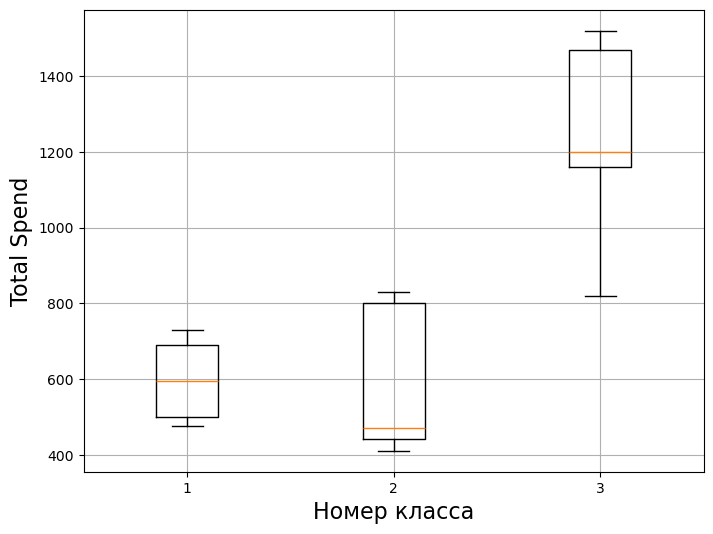

In [12]:
# 3. Построй boxplot: Total Spend по каждому классу Satisfaction Level.
plt.figure(figsize=(8,6))
df_po_classam = [df[df['satisfaction_encoded'] == i]['Total Spend'] for i in range(3)]
plt.boxplot(df_po_classam)
plt.grid(True)
plt.xlabel('Номер класса', fontsize=16)
plt.ylabel('Total Spend', fontsize=16)
plt.show()

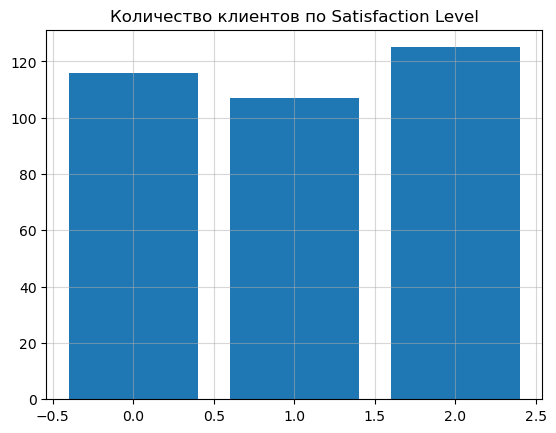

In [13]:
# 4. Построй countplot для Satisfaction Level (количество клиентов в каждом классе).
counts = df['satisfaction_encoded'].value_counts()
plt.bar(counts.index, counts.values)
plt.grid(True, alpha=0.5)
# Либо второй вариант через одну строку sns.countplot(data=df, x='satisfaction_encoded')
plt.title('Количество клиентов по Satisfaction Level')
plt.show()

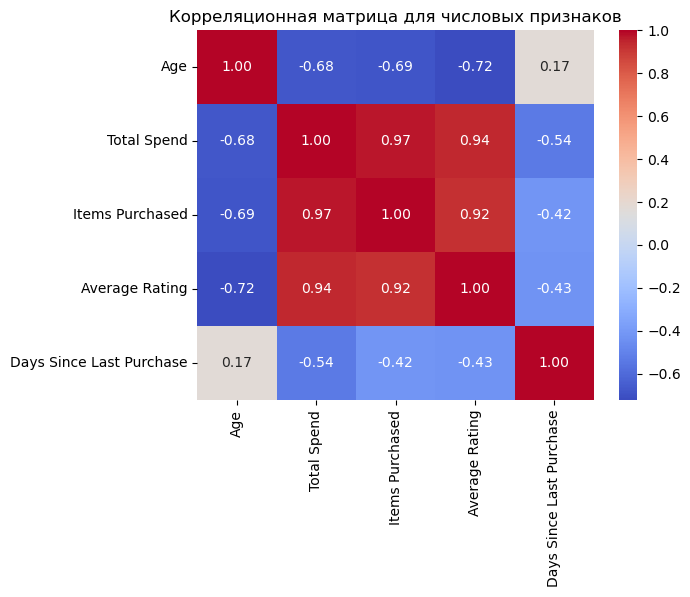

In [14]:
# 5. Построй тепловую карту корреляций между всеми числовыми признаками (не включая закодированные категории).
df_copy = pd.read_csv('customer_behavior.csv')
df_copy.drop('Customer ID', axis=1, inplace=True)
cols_required = []
for col, dtype in zip(df_copy.dtypes.index, df_copy.dtypes.values):
    if dtype == 'float64' or dtype == 'int64':
        cols_required.append(col)
sns.heatmap(data =df_copy[cols_required].corr(), annot=True,fmt='.2f', cmap='coolwarm')
plt.title("Корреляционная матрица для числовых признаков")
plt.show()

<Axes: xlabel='Items Purchased', ylabel='Count'>

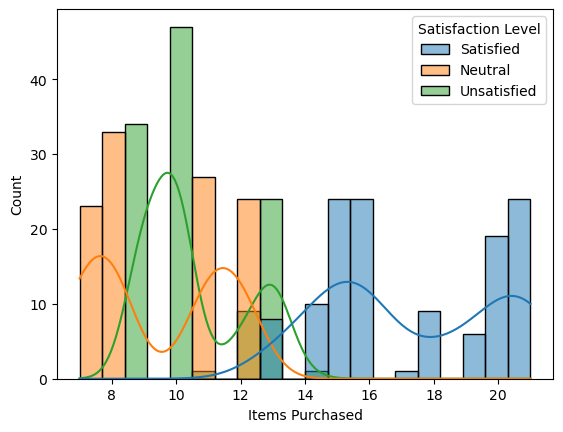

In [15]:
# 6. Построй гистограмму распределения Items Purchased с разбивкой по Satisfaction Level (hue).
sns.histplot(data=df_copy, x='Items Purchased', bins=20, hue='Satisfaction Level', kde=True)

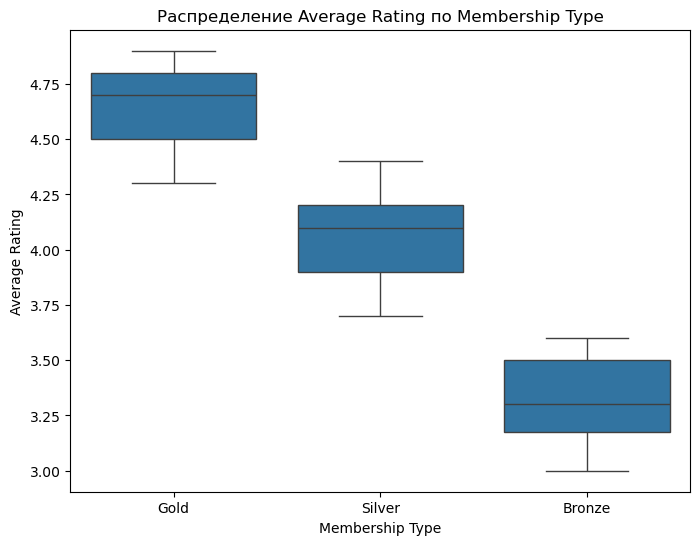

In [16]:
# 7. Построй boxplot: Average Rating по Membership Type.
plt.figure(figsize=(8,6))
sns.boxplot(data = df_copy, y = 'Average Rating', x = 'Membership Type')
plt.title("Распределение Average Rating по Membership Type")
plt.show()

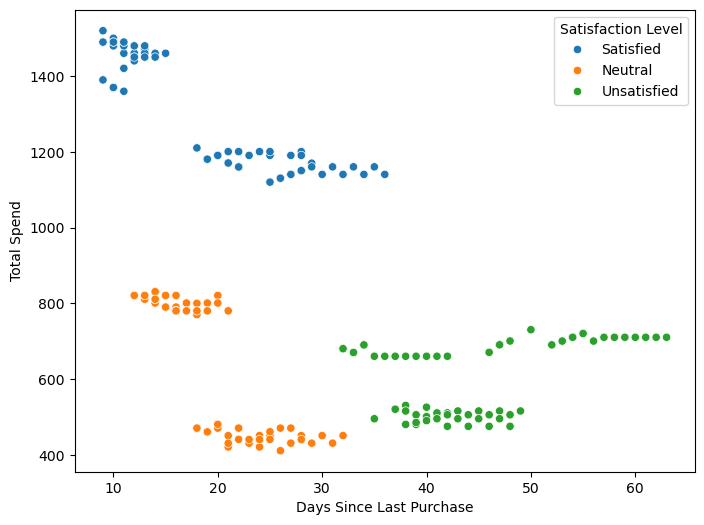

In [17]:
# 8. Построй scatterplot: Days Since Last Purchase (x) vs Total Spend (y), раскрасив точки по Satisfaction Level.
plt.figure(figsize=(8,6))
sns.scatterplot(data=df_copy, x='Days Since Last Purchase', y='Total Spend', hue='Satisfaction Level')
plt.show()

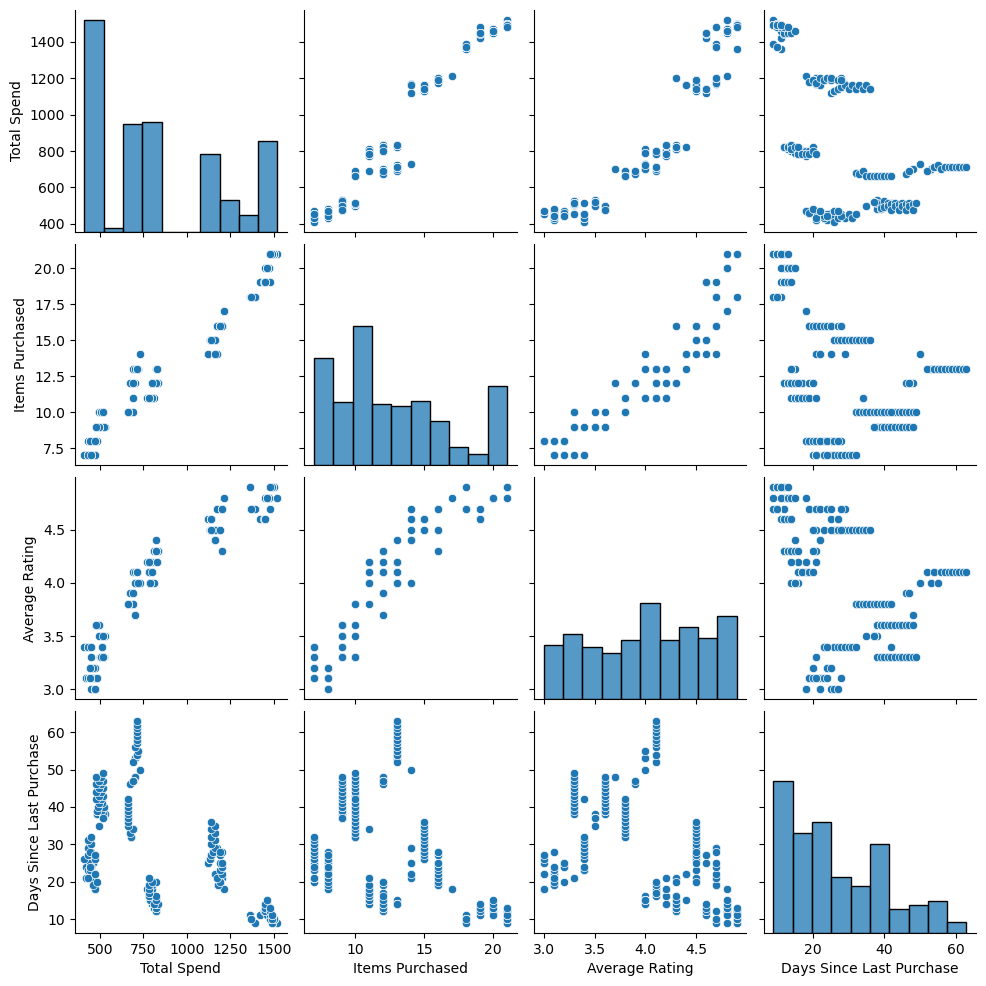

In [18]:
# 9. Построй pairplot для колонок: Total Spend, Items Purchased, Average Rating, Days Since Last Purchase, с hue='Satisfaction Level'.
sns.pairplot(data =df_copy[['Total Spend', 'Items Purchased', 'Average Rating', 'Days Since Last Purchase']])
plt.show()

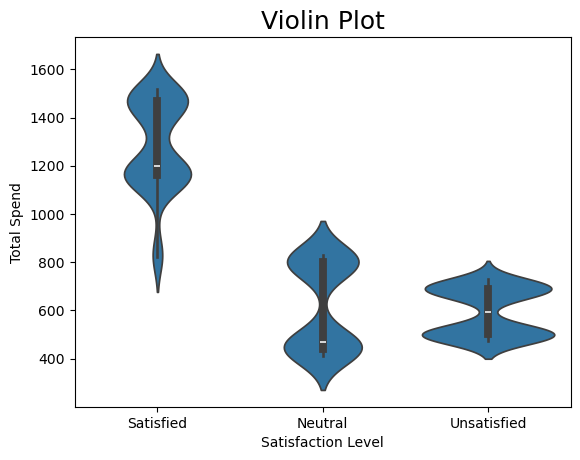

In [19]:
# 10. Построй violinplot: Total Spend по Satisfaction Level.
sns.violinplot(data=df_copy, y= 'Total Spend', x = 'Satisfaction Level')
plt.title('Violin Plot', fontsize=18)
plt.show()

<Axes: xlabel='Total Spend', ylabel='Average Rating'>

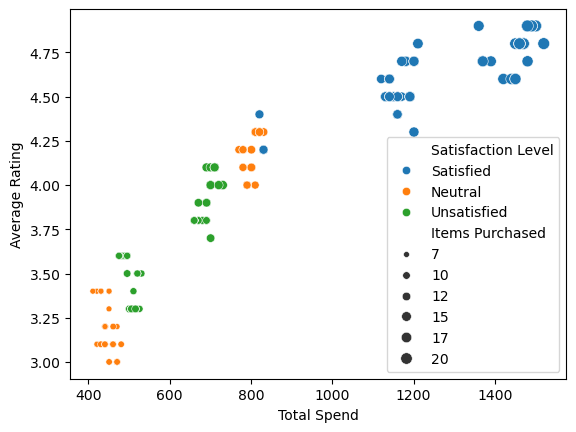

In [20]:
# 11. Построй scatterplot с цветовой кодировкой по Satisfaction Level и размером точек по Items Purchased. 
# Total Spend (x), Average Rating (y)
sns.scatterplot(data=df_copy, x= 'Total Spend', y = 'Average Rating', size='Items Purchased', hue='Satisfaction Level')

<Axes: xlabel='City', ylabel='Total Spend'>

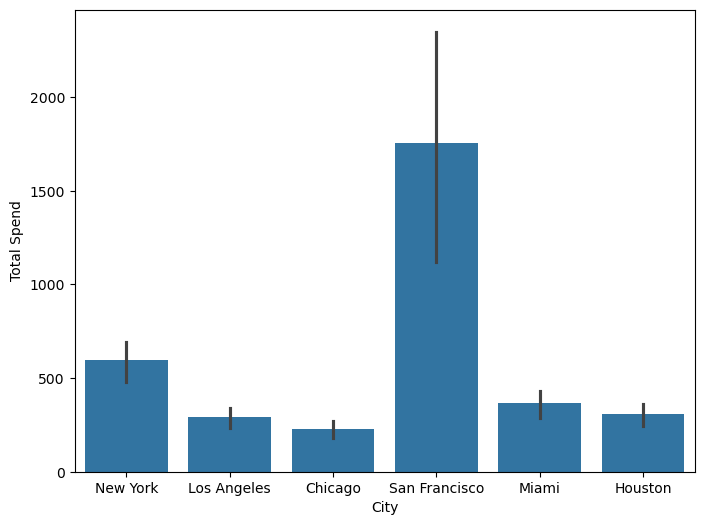

In [21]:
# 12. Построй barplot: дисперсию Total Spend по каждому городу (City) с доверительными интервалами.
plt.figure(figsize=(8,6))
sns.barplot(data = df_copy, x='City', y='Total Spend', errorbar=('ci', 90), estimator=np.var)

## Обучение MLP на этом датасете

In [22]:
!pip install torch

### Разделение и стандартизация данных
 Поскольку датасет маленький, MLP может показать плохой результат. Позже сравним его с другими моделями

In [23]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

X, y = df.drop('satisfaction_encoded', axis = 1), df['satisfaction_encoded']
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, shuffle=True, stratify=y, test_size=0.4)
print(f"{len(X_train)} and {len(y_test)}")
print(df.shape)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
y_train = np.array(y_train)
y_test = np.array(y_test)

208 and 140
(348, 14)


In [24]:
X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32)
X_test_t = torch.tensor(X_test_scaled, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)
y_test_t = torch.tensor(y_test, dtype=torch.long)

In [25]:
class MyMLP(nn.Module):
    def __init__(self, input_size, func_activation, dropout_proba = 0.15):
        super().__init__()
        self.fc1 = nn.Linear(input_size, 6)
        self.fc3 = nn.Linear(6, 3)
        self.activation = func_activation
        self.dp1 = nn.Dropout(dropout_proba)
    def forward(self, x):
        x = self.activation(self.fc1(x))
        x = self.dp1(x)
        return self.fc3(x)
    def predict_proba(self, x_test):
        with torch.no_grad():
            logits = self(x_test)
            return torch.softmax(logits, dim=1)
    def predict(self, x_test):
        with torch.no_grad():
            logits = self(x_test)
            return torch.argmax(logits, dim=1)

train_loss = []
test_loss = []
batch_size=32
dataset_train = TensorDataset(X_train_t, y_train_t)
dataset_test = TensorDataset(X_test_t, y_test_t)
dataloader = DataLoader(
        dataset_train,
        batch_size=32,
        shuffle=True
)
dataloader_test = DataLoader(
        dataset_test,
        batch_size=32,
        shuffle=True
)
mlp = MyMLP(input_size=len(X_train_t[0]), func_activation=torch.relu)
criterion = nn.CrossEntropyLoss()
optimizator = optim.SGD(mlp.parameters(), lr=0.001, nesterov=True, momentum=0.9)
epochs = 200
for epoch in range(epochs):
    mlp.train()
    batch_average_loss_train = 0
    batch_average_loss_test = 0
    for X_batch, y_batch in dataloader:
        optimizator.zero_grad()
        pred = mlp(X_batch)
        loss = criterion(pred, y_batch)
        batch_average_loss_train += loss.item()    
        loss.backward()
        optimizator.step()
    batch_average_loss_train /= len(dataloader)
    train_loss.append(batch_average_loss_train)
    mlp.eval()
    with torch.no_grad():
        for X_batch_test, y_batch_test in dataloader_test:
            preds = mlp(X_batch_test)
            loss_test = criterion(preds, y_batch_test)
            batch_average_loss_test += loss_test.item()
    batch_average_loss_test /= len(dataloader)
    test_loss.append(batch_average_loss_test)
    if epoch % 50 == 0:
        print(f'Epoch {epoch}, loss = {batch_average_loss_train:.4f}, loss_test = {batch_average_loss_test:.4f}')

Epoch 0, loss = 1.2004, loss_test = 0.8572
Epoch 50, loss = 0.4494, loss_test = 0.2520
Epoch 100, loss = 0.2580, loss_test = 0.0770
Epoch 150, loss = 0.1854, loss_test = 0.0406


In [26]:
mlp.eval()
with torch.no_grad():
    logits = mlp(X_test_t)
    preds = torch.argmax(logits, dim=1)
acc = accuracy_score(y_test_t, preds)
precision = precision_score(y_test_t, preds, average='macro')
recall = recall_score(y_test_t, preds, average='macro')
print(f"Accuracy on test: {acc:.4f}, Pecision on test: {precision:.4f}, Recall on test: {recall:.4f}")

Accuracy on test: 0.9929, Pecision on test: 0.9924, Recall on test: 0.9933


#### Датасет слишком маленький, поэтому MLP переобучился, что и следовало ожидать. Чуть позже это будет видно из графиков 

## Оценка качества модели. Сравним ее с более "честной" моделью LogReg, которая лучше справляется с маленьким датасетами

In [27]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

X_train_lr, X_test_lr, y_train_lr, y_test_lr = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

scaler_lr = StandardScaler()
X_train_lr = scaler.fit_transform(X_train_lr)
X_test_lr = scaler.transform(X_test_lr)

model_lr = LogisticRegression(multi_class='ovr', max_iter=1000, C=1.0, random_state=42)
model_lr.fit(X_train_lr, y_train_lr)

y_pred_lr = model_lr.predict(X_test_lr)
y_proba_lr = model_lr.predict_proba(X_test_lr)

print(f'Accuracy: {accuracy_score(y_test_lr, y_pred_lr):.4f}')
print(f'Precision (macro): {precision_score(y_test_lr, y_pred_lr, average="macro"):.4f}')
print(f'Recall (macro): {recall_score(y_test_lr, y_pred_lr, average="macro"):.4f}')
print(f'F1 (macro): {f1_score(y_test_lr, y_pred_lr, average="macro"):.4f}')
#cross_val_score(model_lr, X, y, cv=5, scoring='f1_macro')

Accuracy: 0.9905
Precision (macro): 0.9899
Recall (macro): 0.9912
F1 (macro): 0.9904


D:\Anaconda\Lib\site-packages\sklearn\linear_model\_logistic.py:1281: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


#### Получаем predict-ы для нейросети, которые понадобятся в дальнейшем.

In [28]:
mlp.eval()
with torch.no_grad():
    logits = mlp(X_test_t)
    y_pred_nn = torch.argmax(logits, dim=1).numpy()
    y_proba_nn = torch.softmax(logits, dim=1).numpy()

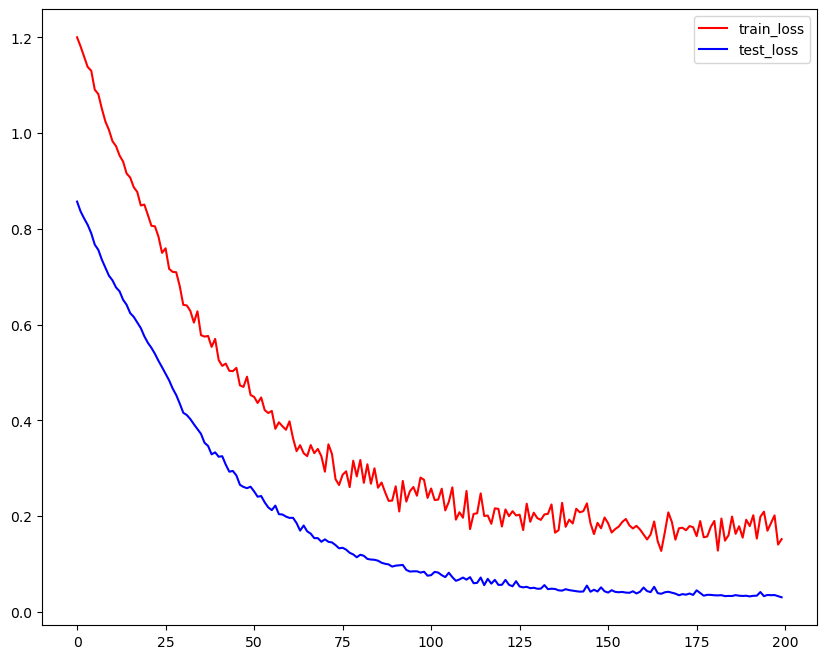

In [29]:
# 1. Построй график train_loss и test_loss по эпохам (2 линии на одном графике).
plt.figure(figsize = (10, 8))
plt.plot(train_loss, color='red', label='train_loss')
plt.plot(test_loss, color='blue', label='test_loss')
plt.legend()
plt.show()

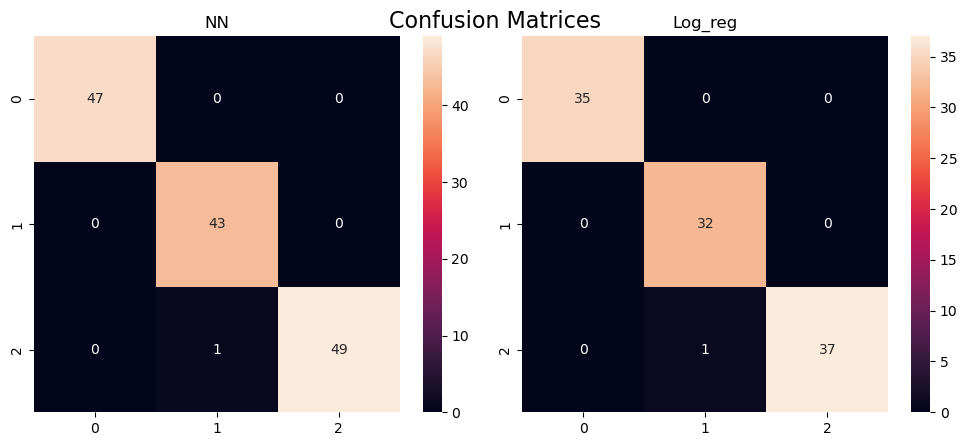

In [30]:
# Задача 2. Построй confusion matrix (sns.heatmap) для логистической регрессии.
# Сравни с матрицей для нейросети (где все предсказания идеальны).
cm_nn = pd.DataFrame(confusion_matrix(y_test_t, y_pred_nn), index=range(3), columns=range(3))
cm_log_reg = pd.DataFrame(confusion_matrix(y_test_lr, y_pred_lr), index=range(3), columns=range(3))
figure, matrices = plt.subplots(1,2,figsize = (10, 4.5))
sns.heatmap(annot=True, data=cm_nn, ax=matrices[0])
matrices[0].set_title('NN')
sns.heatmap(annot=True, data=cm_log_reg, ax=matrices[1])
matrices[1].set_title('Log_reg')
plt.tight_layout()
figure.suptitle("Confusion Matrices", fontsize=16)
plt.show()

In [31]:
# Задача 3. Построй PR-кривую для логистической регрессии по какому нибудь классу.
# Сравни с PR-кривой для нейросети (нарисуй на одном графике или рядом).
### Когда threshold == 1 тогда мы про все говорим что это "НЕТ", то есть по минимуму ебем клиентуру. precision = 1 recall = 0
y_test_t = y_test_t.cpu().numpy()

from sklearn.metrics import PrecisionRecallDisplay
thresholds = np.linspace(0, 1, 20)
precisions_nn = [precision_score((y_test_t==2).astype(int), (y_proba_nn[:,2] > threshold).astype(int), zero_division=1) for threshold in thresholds]
recalls_nn = [recall_score((y_test_t==2).astype(int), (y_proba_nn[:,2] > threshold).astype(int), zero_division=0) for threshold in thresholds]
precisions_lr = [precision_score((y_test_lr==2).astype(int), (y_proba_lr[:,2] > threshold).astype(int), zero_division=1) for threshold in thresholds]
recalls_lr = [recall_score((y_test_lr==2).astype(int), (y_proba_lr[:,2] > threshold).astype(int), zero_division=0) for threshold in thresholds]

print(precisions_nn)
print(precisions_lr)
print(recalls_nn)
print(recalls_lr)

[0.35714285714285715, 0.7246376811594203, 0.78125, 0.9090909090909091, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]
[0.3619047619047619, 0.7037037037037037, 0.8837209302325582, 0.9047619047619048, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]
[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.98, 0.98, 0.98, 0.98, 0.98, 0.98, 0.98, 0.98, 0.98, 0.98, 0.98, 0.98, 0.98, 0.0]
[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.9736842105263158, 0.9736842105263158, 0.9736842105263158, 0.9736842105263158, 0.9736842105263158, 0.9736842105263158, 0.9736842105263158, 0.9736842105263158, 0.9736842105263158, 0.9736842105263158, 0.9736842105263158, 0.9736842105263158, 0.9736842105263158, 0.0]


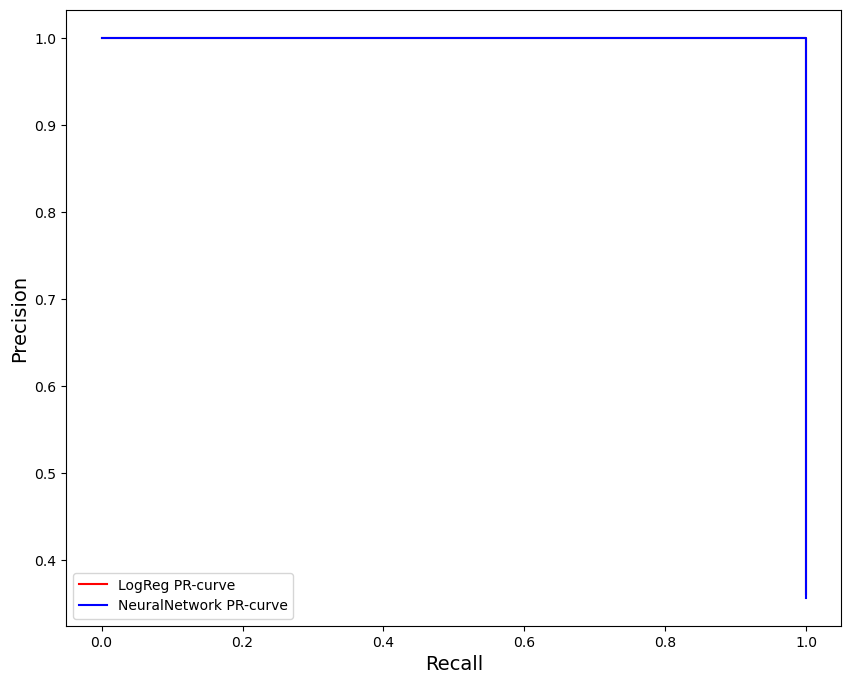

In [32]:
plt.figure(figsize = (10.,8))
plt.plot(recalls_lr, precisions_lr, color = 'red', label='LogReg PR-curve')
plt.plot(recalls_nn, precisions_nn, color = 'blue', label='NeuralNetwork PR-curve')
plt.xlabel('Recall', fontsize=14)
plt.ylabel('Precision', fontsize=14)
plt.legend()
plt.show()

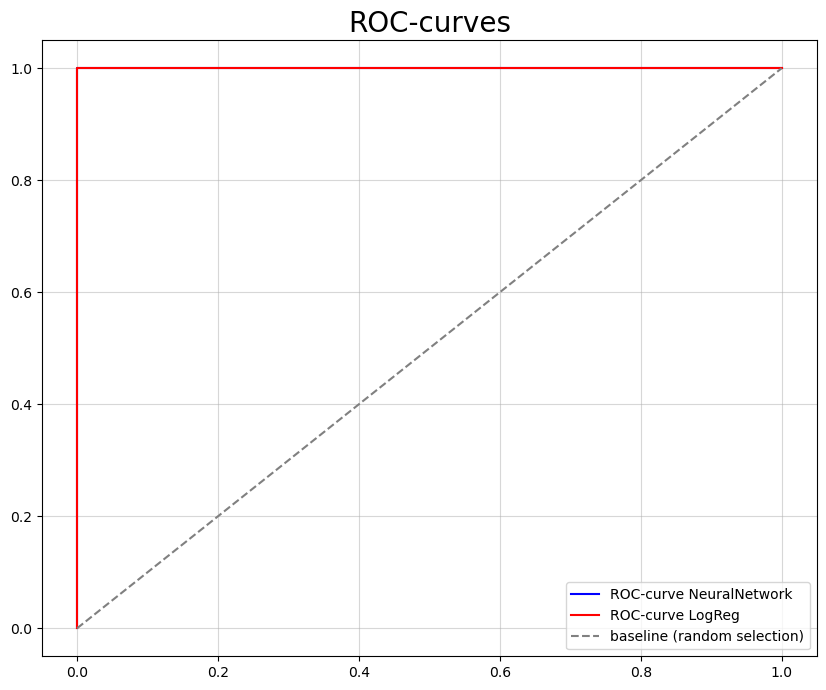

In [33]:
# Задача 4. Построй ROC-кривую и AUC для логистической регрессии.
# Сравни с ROC-кривой для нейросети (на одном графике).
FPR_nn = [confusion_matrix((y_test_t==2).astype(int), (y_proba_nn[:,2] > threshold).astype(int))[0][1]/confusion_matrix((y_test_t==2).astype(int), (y_proba_nn[:,2] > threshold).astype(int))[0].sum() for threshold in thresholds]
FPR_lr = [confusion_matrix((y_test_lr==2).astype(int), (y_proba_lr[:,2] > threshold).astype(int))[0][1]/confusion_matrix((y_test_lr==2).astype(int), (y_proba_lr[:,2] > threshold).astype(int))[0].sum() for threshold in thresholds]
plt.figure(figsize=(10,8))
plt.plot(FPR_nn, recalls_nn, color='blue', label='ROC-curve NeuralNetwork')
plt.plot(FPR_lr, recalls_lr, color='red', label='ROC-curve LogReg')
plt.title('ROC-curves', fontsize=20)
plt.grid(True, alpha=0.5)
plt.plot([0,1], [0,1], ls='--', color='gray', label = 'baseline (random selection)')
plt.legend()
plt.show()

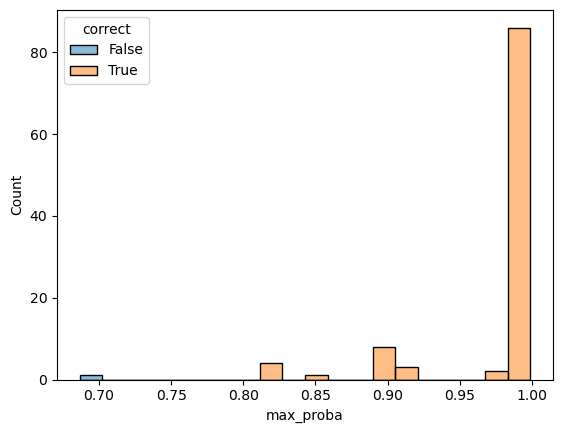

In [34]:
# Задача 5. Построй гистограмму вероятностей (predict_proba) для правильно и неправильно предсказанных объектов для логистической регрессии.
max_proba = [el.max() for el in y_proba_lr]
correct_lr = (y_pred_lr == y_test_lr)
df = pd.DataFrame({
    'max_proba': max_proba,
    'correct': correct_lr
})

sns.histplot(data=df, x='max_proba', hue='correct', alpha=0.5, bins=20)
plt.show()

## Вывод
<span style="font-size: 16px;">Датасет слишком маленький, из-за чего нейросеть сильно переобучилась (ниже ячейка с кросс валидацией), несмотря на то что имеет довольно простую архитектуру, а Лог рег показала неплохой результат.

In [43]:
import torch
import torch.nn as nn
import numpy as np
from sklearn.model_selection import cross_val_score
from sklearn.base import BaseEstimator, ClassifierMixin

class PyTorchMLPWrapper(BaseEstimator, ClassifierMixin):
    def __init__(self, input_size, hidden=6, lr=0.01, epochs=100):
        self.input_size = input_size
        self.hidden = hidden
        self.lr = lr
        self.epochs = epochs
        self.model = None
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    def _build_model(self):
        class MLP(nn.Module):
            def __init__(self, input_size, hidden):
                super().__init__()
                self.fc1 = nn.Linear(input_size, hidden)
                self.fc2 = nn.Linear(hidden, 3)  # выход на 3 класса

            def forward(self, x):
                x = torch.relu(self.fc1(x))
                return self.fc2(x)  # без dropout, чтобы не усложнять

        return MLP(self.input_size, self.hidden).to(self.device)

    def fit(self, X, y):
        X = torch.tensor(X.values, dtype=torch.float32).to(self.device)
        y = torch.tensor(y, dtype=torch.long).to(self.device)

        self.model = self._build_model()
        criterion = nn.CrossEntropyLoss()
        optimizer = torch.optim.SGD(self.model.parameters(), lr=self.lr, momentum=0.9, nesterov=True)

        self.model.train()
        for epoch in range(self.epochs):
            optimizer.zero_grad()
            pred = self.model(X)
            loss = criterion(pred, y)
            loss.backward()
            optimizer.step()

        return self

    def predict(self, X):
        self.model.eval()
        with torch.no_grad():
            X = torch.tensor(X.values, dtype=torch.float32).to(self.device)
            logits = self.model(X)
            preds = torch.argmax(logits, dim=1)
        return preds.cpu().numpy()

X, y = df_copy_cv.drop('satisfaction_encoded', axis = 1).astype(np.float32), df_copy_cv['satisfaction_encoded'].values

# Кросс-валидация
model = PyTorchMLPWrapper(input_size=X.shape[1], epochs=100)
scores = cross_val_score(model, X, y, cv=5, scoring='accuracy')

print(f'Cross-val accuracy: {scores.mean():.4f} (+/- {scores.std():.4f})')
print(f'Scores per fold: {scores}')

Cross-val accuracy: 0.3591 (+/- 0.0182)
Scores per fold: [0.38571429 0.35714286 0.37142857 0.34782609 0.33333333]


In [44]:
df_copy_cv

,Age,Total Spend,Items Purchased,Average Rating,Discount Applied,Days Since Last Purchase,membership_encoded,City_Chicago,City_Houston,City_Los Angeles,City_Miami,City_New York,City_San Francisco,satisfaction_encoded
0,29,1120.20,14,4.6,True,25,2,False,False,False,False,True,False,2
1,34,780.50,11,4.1,False,18,1,False,False,True,False,False,False,1
2,43,510.75,9,3.4,True,42,0,True,False,False,False,False,False,0
3,30,1480.30,19,4.7,False,12,2,False,False,False,False,False,True,2
4,27,720.40,13,4.0,True,55,1,False,False,False,True,False,False,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
345,32,660.30,10,3.8,True,42,1,False,False,False,True,False,False,0
346,36,470.50,8,3.0,False,27,0,False,True,False,False,False,False,1
347,30,1190.80,16,4.5,True,28,2,False,False,False,False,True,False,2
348,34,780.20,11,4.2,False,21,1,False,False,True,False,False,False,1
